In [57]:
from QHED import *

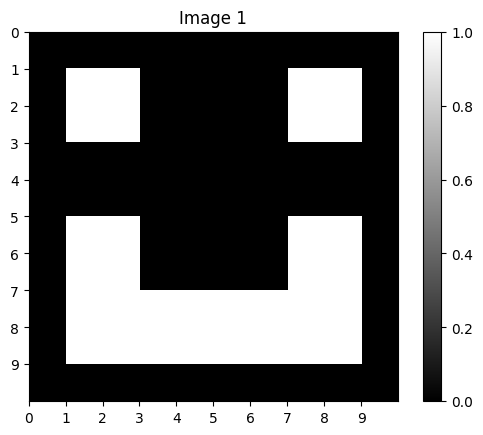

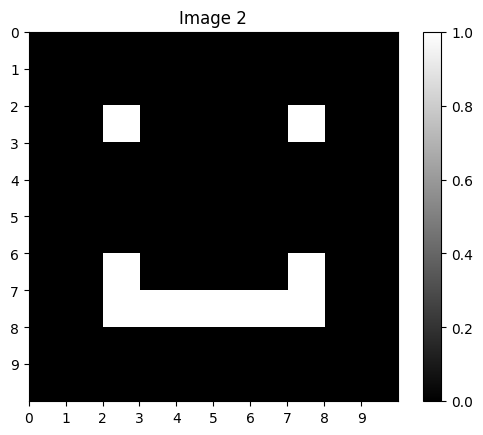

In [58]:
img1 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                 [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                 [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                 [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
                 [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

img2 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
norm_img1 = normalize_image(img1)
norm_img2 = normalize_image(img2)

plot_image(img1, 'Image 1')
plot_image(img2, 'Image 2')

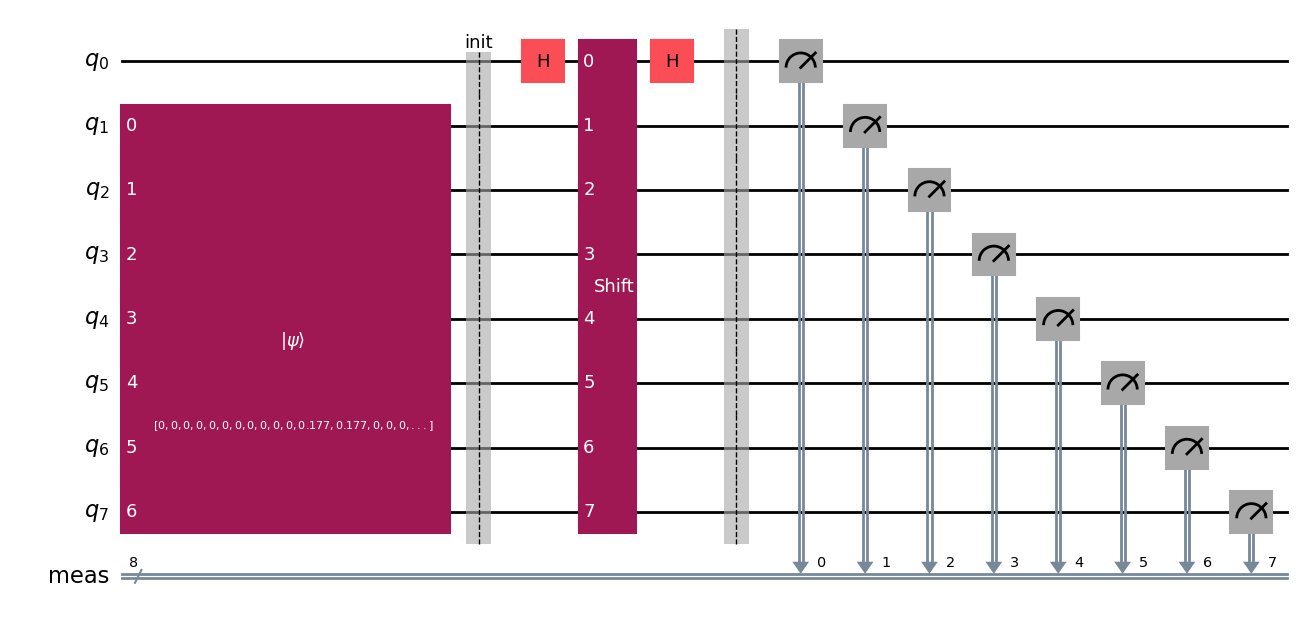

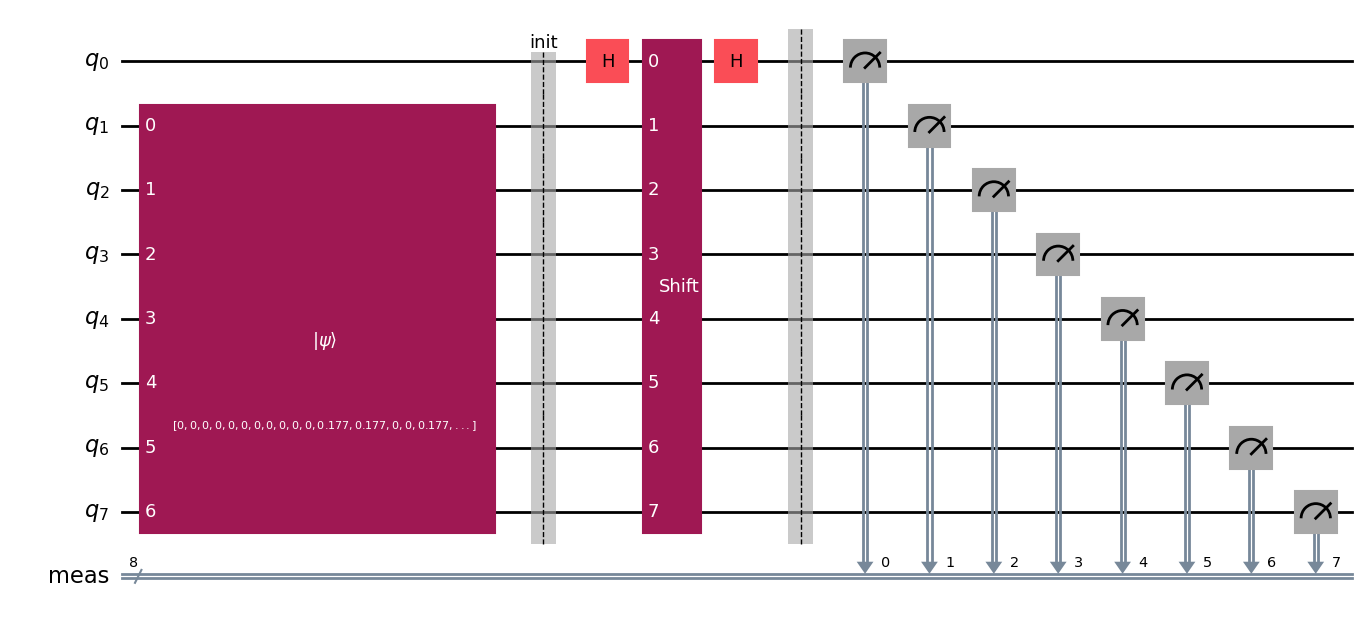

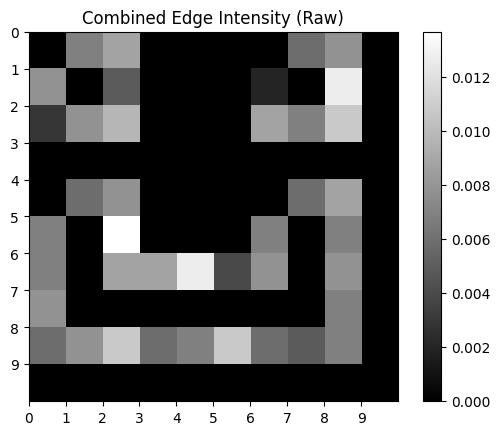

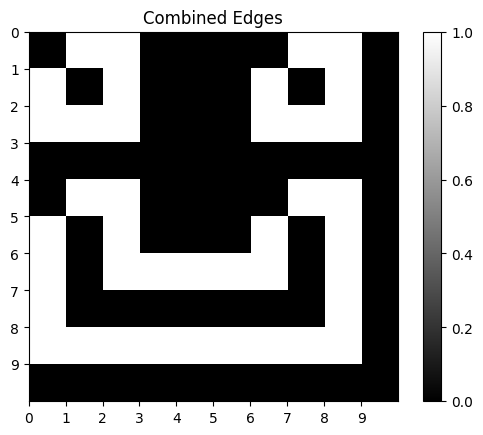

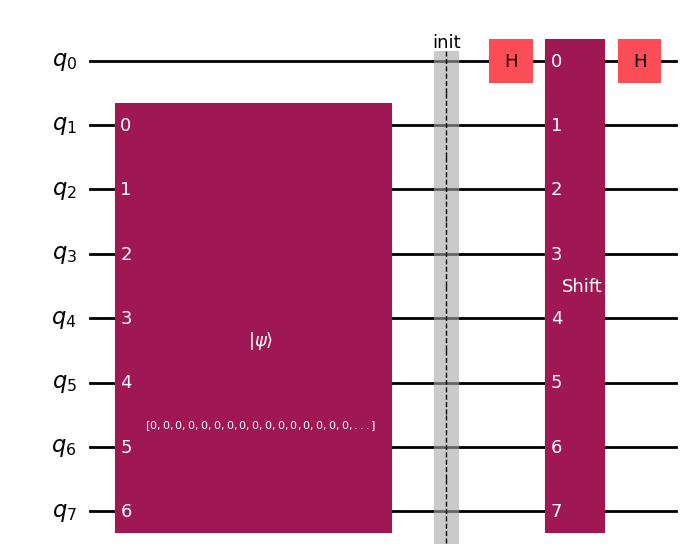

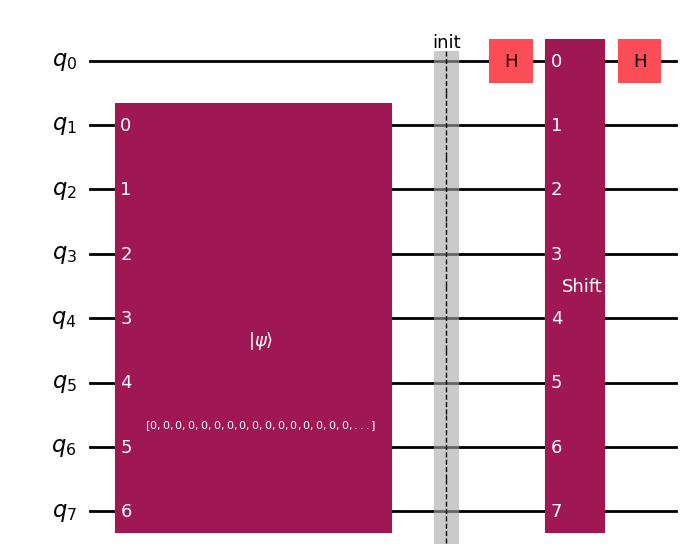

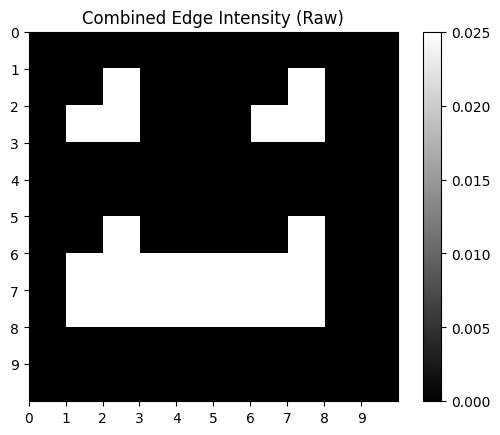

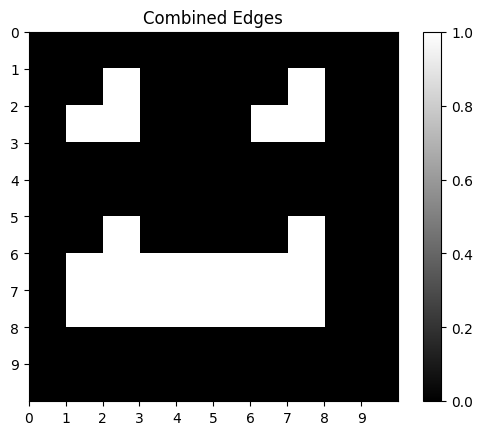

In [59]:
# test with measurement
qhed1 = QHED(img1, measure=True, display=True)
qhed1.plot_raw_results()
qhed1.plot_results()

qhed2 = QHED(img2, measure=False, display=True)
qhed2.plot_raw_results()
qhed2.plot_results()

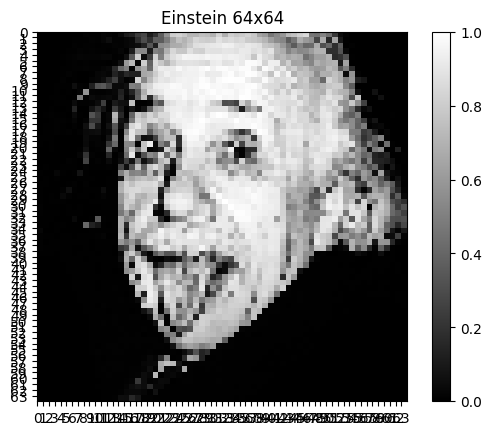

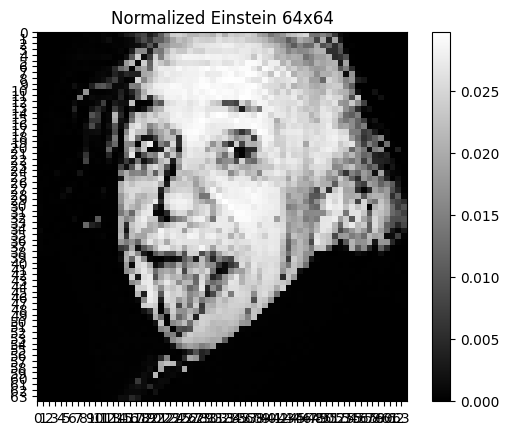

Einstein statevector mode result count: 2


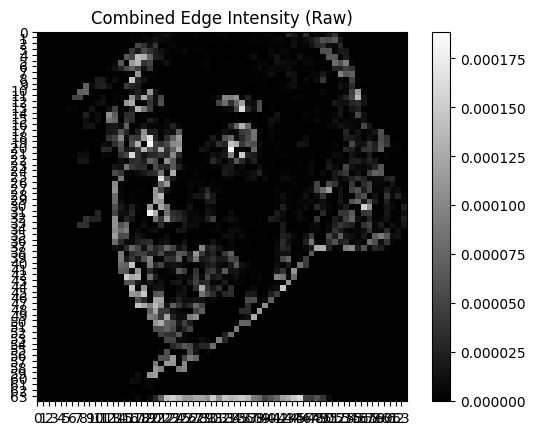

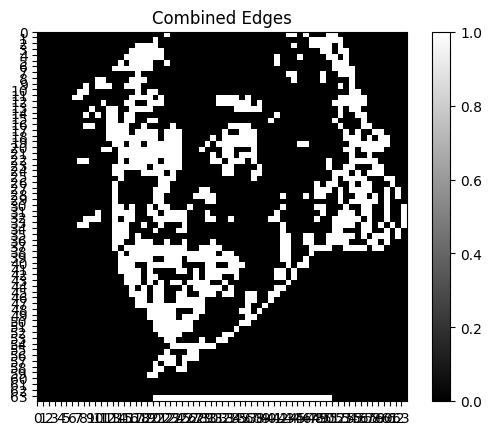

In [60]:
# try on Einstein image (downsampled to keep statevector simulation tractable)
img = plt.imread('einstein.png')
# Convert to grayscale & ensure it's a float64 array for processing.
img_gray = np.mean(img[..., :3], axis=2) if img.ndim == 3 else img
img_gray = np.asarray(img_gray, dtype=np.float64)

# Resize with index mapping
# Recreate the image from the original every few pixels to get a smaller image without recompressing.
target_h, target_w = 64, 64
r_idx = np.linspace(0, img_gray.shape[0] - 1, target_h).astype(int)
c_idx = np.linspace(0, img_gray.shape[1] - 1, target_w).astype(int)
img_small = img_gray[np.ix_(r_idx, c_idx)]

plot_image(img_small, 'Einstein 64x64')
norm_img = normalize_image(img_small)
plot_image(norm_img, 'Normalized Einstein 64x64')

# now run QHED on normalized, downsampled data.
qhed_einstein = QHED(norm_img, measure=False, display=False)
print('Einstein statevector mode result count:', len(qhed_einstein.results))
qhed_einstein.plot_raw_results()
qhed_einstein.plot_results()

In [61]:
# driver to show multuple runs of different resolutions and different postprocessing methods (sobel, finite diff, qhed raw, qhed binary)
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt


def resize_image(img, h, w):
    # resize image similarly to before but more modular for any size
    r = np.linspace(0, img.shape[0] - 1, h).astype(int)
    c = np.linspace(0, img.shape[1] - 1, w).astype(int)
    return img[np.ix_(r, c)]


def sobel_map(img):
    # use scipy's sobel filter to get an edge map for comparison.
    gx = ndimage.sobel(img, axis=1, mode="reflect")
    gy = ndimage.sobel(img, axis=0, mode="reflect")
    return np.hypot(gx, gy)


def finite_diff_map(img):
    # simple finite difference edge map (not as good as sobel but very simple and fast, and shows the basic idea of edge detection as looking for changes in pixel values).
    gx = np.zeros_like(img, dtype=float)
    gy = np.zeros_like(img, dtype=float)
    gx[:, :-1] = img[:, 1:] - img[:, :-1]
    gy[:-1, :] = img[1:, :] - img[:-1, :]
    return np.maximum(np.abs(gx), np.abs(gy))


def qhed_raw_map(qhed_obj):
    # combine the raw QHED results into a single edge map by taking the maximum probability across all results for each pixel. (no threshold)
    maps = []
    for idx, result in enumerate(qhed_obj.results):
        flat_probs = qhed_obj.result_to_flat_probabilities(result)
        maps.append(qhed_obj.flat_to_edge_image(flat_probs, idx))
    return np.maximum(maps[0], maps[1])


def qhed_binary_map(qhed_obj, threshold):
    # final data output for qhed with given threshold value
    maps = []
    for idx, result in enumerate(qhed_obj.results):
        flat_probs = qhed_obj.result_to_flat_probabilities(result)
        flat_edges = (flat_probs > threshold).astype(int)
        maps.append(qhed_obj.flat_to_edge_image(flat_edges, idx))
    return np.logical_or(maps[0], maps[1]).astype(int)


def run_size_comparison(img_gray, sizes, threshold=1e-5):
    # run all the different edge detection methods on the image at different sizes and return the results (QHED and classical)
    records = []
    for size in sizes:
        img_small = resize_image(img_gray, size, size)
        qhed = QHED(img_small, measure=False, display=False, edge_threshold=threshold)
        records.append({
            "size": size,
            "image": img_small,
            "raw_qhed": qhed_raw_map(qhed),
            "binary_qhed": qhed_binary_map(qhed, threshold),
            "finite_diff": finite_diff_map(img_small),
            "sobel": sobel_map(img_small),
            "qhed_obj": qhed,
        })
    return records

def plot_size_comparison(records):
    # format the data in to a table
    labels = ["Raw Image", "Raw QHED", "Binary QHED", "Finite Diff", "Sobel"]
    fig, axes = plt.subplots(len(records), 5, figsize=(15, 3.2 * len(records)))

    for i, record in enumerate(records):
        images = [record["image"],record["raw_qhed"],record["binary_qhed"],record["finite_diff"],record["sobel"]]

        # set y-axis titles
        axes[i, 0].set_ylabel(f"{record['size']}x{record['size']}", rotation=0, labelpad=36, va="center")
        for j, img in enumerate(images):
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].set_title(labels[j], fontsize=10)
            # hide all y-axis titles except the first
            axes[i, j].axis("on" if j == 0 else "off")
            # need to hide the ticks (no need for them)
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

    fig.suptitle("QHED vs Classical Edge Baselines by Size")
    plt.tight_layout()
    fig.subplots_adjust(left=0.10)
    plt.show()


def make_thresholds(qhed_obj, n=6, min_ratio=1e-3):
    # make a set of thresholds to sweep over for the binary edge map
    # spaced logarithmically
    max_val = np.max(qhed_raw_map(qhed_obj))
    if max_val <= 0:
        return [0.0]
    return [0.0] + list(np.geomspace(max_val * min_ratio, max_val, n - 1))


def plot_threshold_sweep(qhed_obj, thresholds):
    # plot the binary edge maps for a set of thresholds
    cols = min(3, len(thresholds))
    rows = int(np.ceil(len(thresholds) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, t in enumerate(thresholds):
        edges = qhed_binary_map(qhed_obj, t)
        axes[i].imshow(edges, cmap="gray")
        axes[i].set_title(f"Threshold = {t:.2e}" if t != 0 else "Threshold = 0")
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


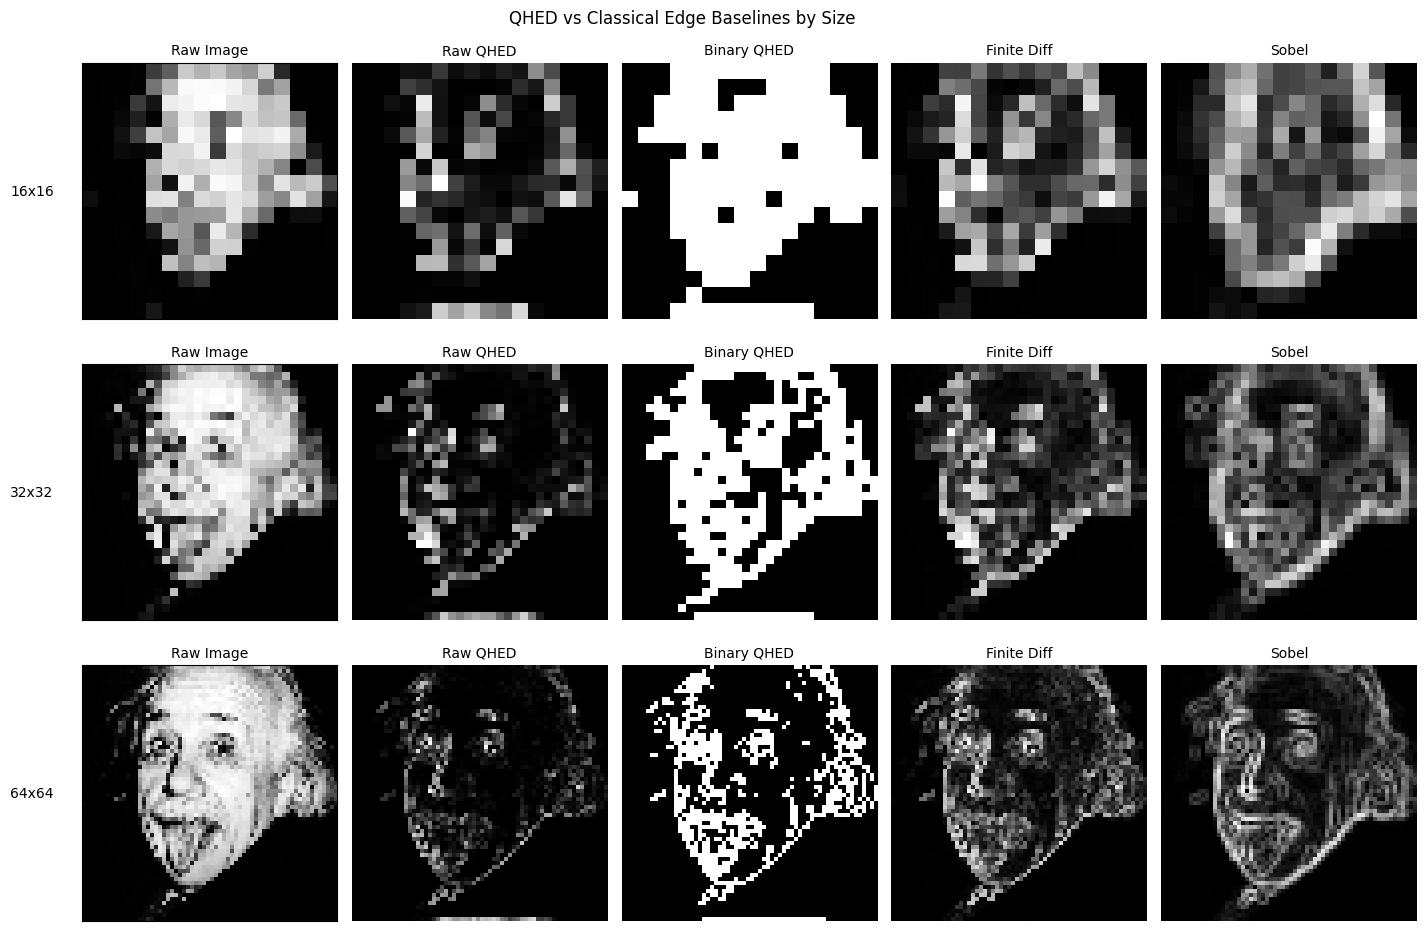

In [62]:
# plotting different einstein image sizes
einstein_gray = plt.imread("einstein.png")
if einstein_gray.ndim == 3:
    einstein_gray = np.mean(einstein_gray[..., :3], axis=2)
einstein_gray = np.asarray(einstein_gray, dtype=np.float64)

records = run_size_comparison(einstein_gray, [16, 32, 64], threshold=1e-5)
plot_size_comparison(records)

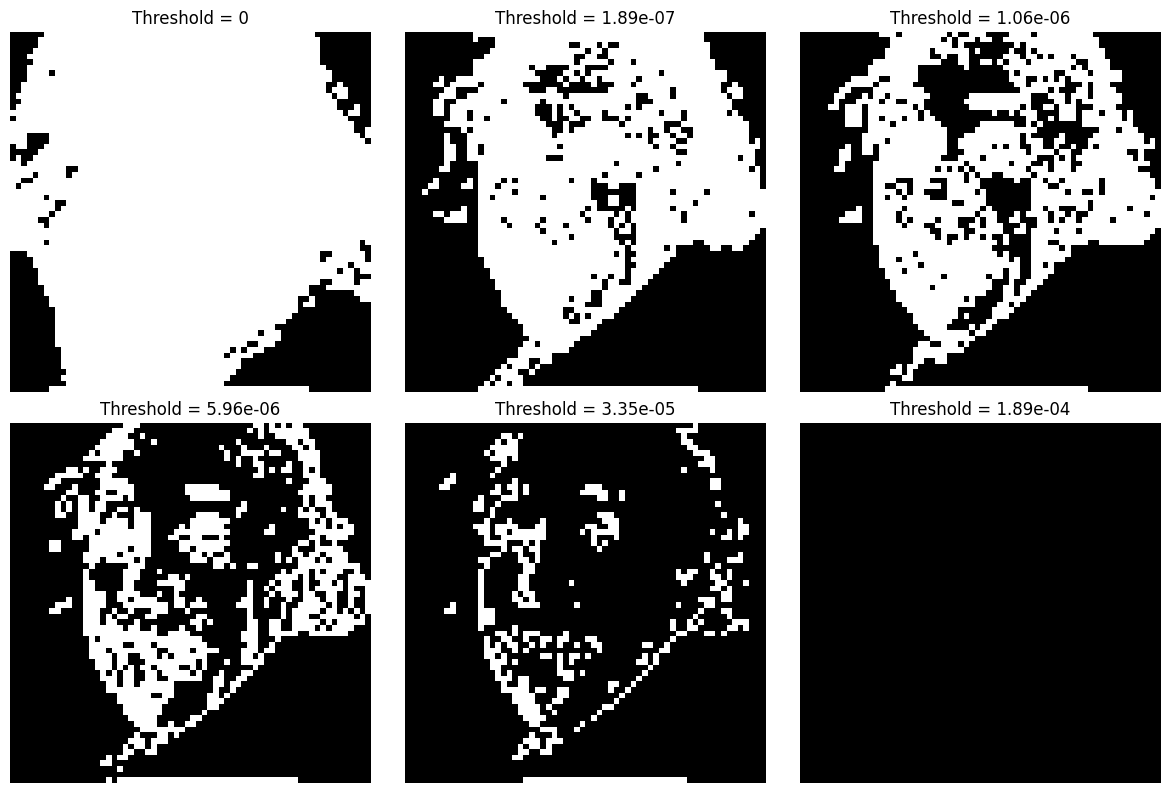

In [63]:
# take the last qhed object (64x64) and plot a threshold sweep to show how the binary edge output changes with threshold.
qhed_64 = records[-1]["qhed_obj"]
thresholds = make_thresholds(qhed_64, n=6)
plot_threshold_sweep(qhed_64, thresholds)